In [1]:
import os
import pandas as pd
import numpy as np
import re
import utils
import matplotlib.pyplot as plt

In [2]:
# Make output folder
output_dir = os.path.join('..','..','..','phd_1_analysis','plots','modelling')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
preprocessed_model_fit_folder = f'/Volumes/project/3025011.02/pre-processed/modelling/model_fit'
model_fit_pattern = re.compile(r'^model_fit_sub-\d{3}_session-\d{2}\.csv$')

## Which subjects and sessions do we want to include?

In [4]:
unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37] #[5, 10, 13, 14, 15, 16, 20, 22, 23, 25, 27, 28, 29, 30, 32, 37]
unique_sessions = [1, 2, 3, 4]

In [5]:
model_fit_combined = []
# Iterate through files in the folder
for file_name in os.listdir(preprocessed_model_fit_folder):
    if model_fit_pattern.match(file_name):
        path = os.path.join(preprocessed_model_fit_folder, file_name)
        model_fit = pd.read_csv(path, sep=';')
        model_fit_combined.append(model_fit)

model_fit_combined = pd.concat(model_fit_combined, ignore_index=True)
model_fit_combined = model_fit_combined.sort_values(by=['subject', 'session'])
print(model_fit_combined)

    subject  session  trials   model0_ll  model0_q_happy_pull  \
47        5        1     646 -433.348327            -0.007606   
9         5        2     656 -453.861715             0.865969   
19        5        3     655 -451.260352            -0.184581   
10        5        4     660 -453.183480             0.663026   
18       10        1     658 -454.762216            -0.165095   
12       10        2     655 -451.443903             0.661722   
11       10        3     658 -456.060504             0.199729   
8        10        4     654 -453.131677             0.256353   
6        13        1     629 -432.921191             0.762467   
5        13        2     378 -260.599975            -1.000000   
14       14        1     648 -447.990521            -0.442537   
20       14        2     658 -455.494915            -0.225496   
7        14        3     656 -451.129295             0.133436   
13       14        4     655 -453.948784            -0.397579   
16       15        1     

In [6]:
## Only keep the rows with subjects and sessions we want
model_fit_combined = model_fit_combined[
    model_fit_combined['subject'].isin(unique_subject_ids) &
    model_fit_combined['session'].isin(unique_sessions)
]

In [7]:
# Automatically detect models
models = [col.split('_')[0] for col in model_fit_combined.columns if '_ll' in col]
models = sorted(set(models))

In [8]:
# Initialize dictionaries for AIC/BIC
for model in models:
    # Count the number of parameters per model
    param_cols = [col for col in model_fit_combined.columns if col.startswith(model + '_') and col != model + '_ll']
    k = len(param_cols)

    # Get negative log-likelihoods
    ll = model_fit_combined[f'{model}_ll']
    #ll = -neg_ll  # Convert to positive log-likelihood

    # Calculate AIC and BIC
    model_fit_combined[f'{model}_AIC'] = 2 * k - 2 * ll
    model_fit_combined[f'{model}_BIC'] = k * np.log(model_fit_combined['trials']) - 2 * ll

print(model_fit_combined)

    subject  session  trials   model0_ll  model0_q_happy_pull  \
47        5        1     646 -433.348327            -0.007606   
9         5        2     656 -453.861715             0.865969   
19        5        3     655 -451.260352            -0.184581   
10        5        4     660 -453.183480             0.663026   
18       10        1     658 -454.762216            -0.165095   
12       10        2     655 -451.443903             0.661722   
11       10        3     658 -456.060504             0.199729   
8        10        4     654 -453.131677             0.256353   
14       14        1     648 -447.990521            -0.442537   
20       14        2     658 -455.494915            -0.225496   
7        14        3     656 -451.129295             0.133436   
13       14        4     655 -453.948784            -0.397579   
16       15        1     658 -455.832419             0.586850   
15       15        2     659 -456.691448             0.075997   
17       15        3     

In [9]:
# Fixed effects group comparison for AIC and BIC
# Take columns that contain AIC or BIC
aic_bic_cols = [col for col in model_fit_combined.columns if 'AIC' in col or 'll' in col]

# Build the total row as a dict comprehension
total_row = {
    col: model_fit_combined[col].sum()   if col in aic_bic_cols
         else 0
    for col in model_fit_combined.columns
}

# Overwrite the session/subject entries
total_row['subject'] = 'total'
total_row['session'] = 'total'

# Add the total row to the DataFrame
total_df = pd.DataFrame([total_row])
model_fit_combined = pd.concat([model_fit_combined, total_df], ignore_index=True)
print(model_fit_combined)

   subject session  trials     model0_ll  model0_q_happy_pull  \
0        5       1     646   -433.348327            -0.007606   
1        5       2     656   -453.861715             0.865969   
2        5       3     655   -451.260352            -0.184581   
3        5       4     660   -453.183480             0.663026   
4       10       1     658   -454.762216            -0.165095   
5       10       2     655   -451.443903             0.661722   
6       10       3     658   -456.060504             0.199729   
7       10       4     654   -453.131677             0.256353   
8       14       1     648   -447.990521            -0.442537   
9       14       2     658   -455.494915            -0.225496   
10      14       3     656   -451.129295             0.133436   
11      14       4     655   -453.948784            -0.397579   
12      15       1     658   -455.832419             0.586850   
13      15       2     659   -456.691448             0.075997   
14      15       3     65

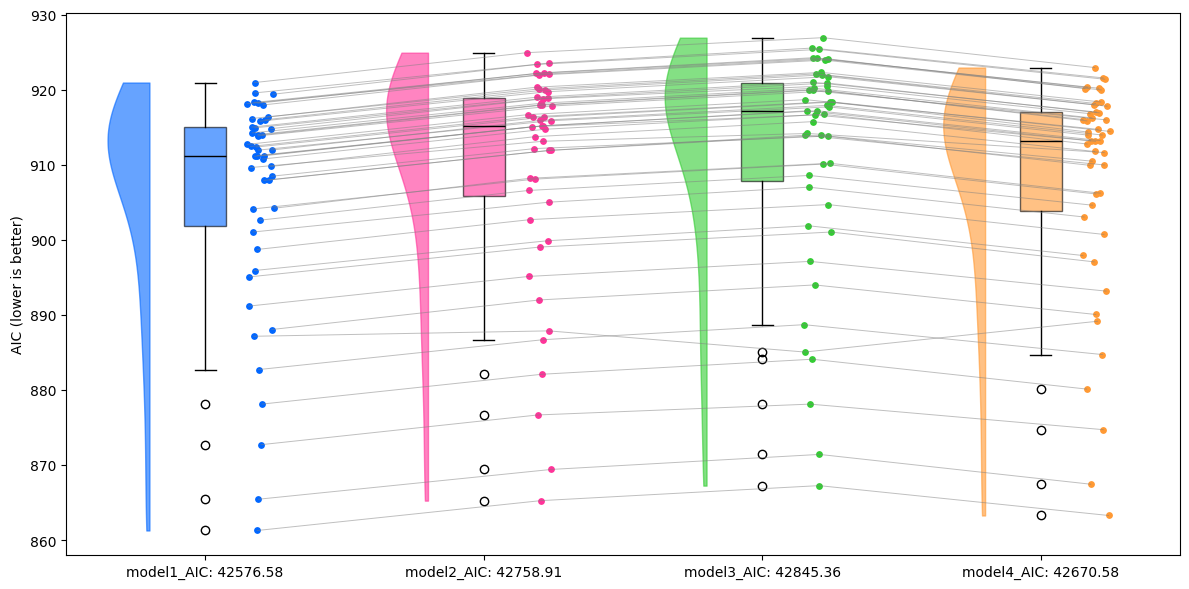

In [10]:
# Remove total column
model_fit_plot = model_fit_combined[model_fit_combined['subject'] != 'total']
model_fit_total = model_fit_combined[model_fit_combined['subject'] == 'total']

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    model_fit_plot,
    columns=['model1_AIC', 'model2_AIC', 'model3_AIC', 'model4_AIC'],
    labels=[f'model1_AIC: {model_fit_total["model1_AIC"].iloc[0]:.2f}', f'model2_AIC: {model_fit_total["model2_AIC"].iloc[0]:.2f}', f'model3_AIC: {model_fit_total["model3_AIC"].iloc[0]:.2f}', f'model4_AIC: {model_fit_total["model4_AIC"].iloc[0]:.2f}'],
    output_dir=output_dir,
    ylabel_name='AIC (lower is better)',
    plot_name='model_comparison_AIC'
)

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/numpy/core/function_base.py:139: RuntimeWarning: invalid value encountered in scalar subtract
  delta = stop - start


IndexError: list index out of range

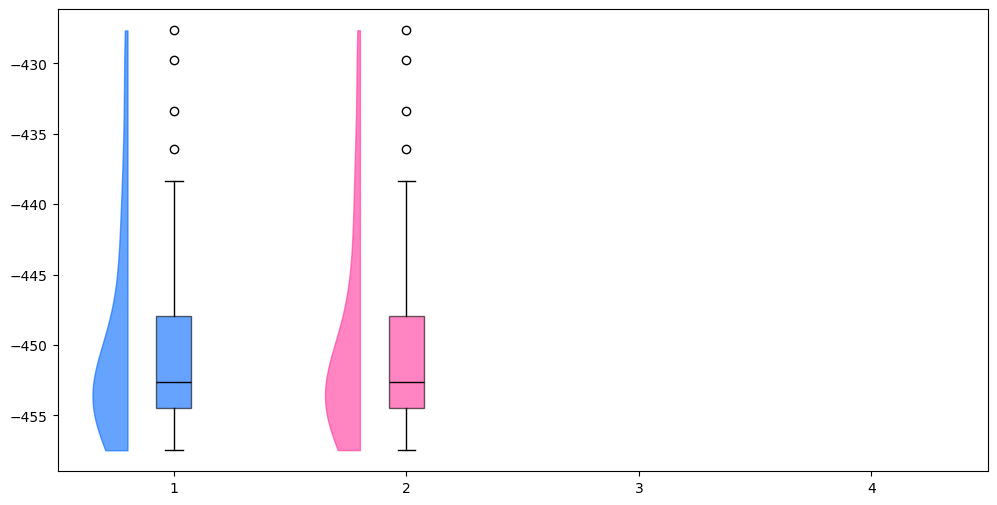

In [11]:
# Remove total column
model_fit_plot = model_fit_combined[model_fit_combined['subject'] != 'total']
model_fit_total = model_fit_combined[model_fit_combined['subject'] == 'total']

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    model_fit_plot,
    columns=['model1_ll', 'model2_ll', 'model5_ll','model6_ll'],
    labels=[f'model1_ll: {model_fit_total["model1_ll"].iloc[0]:.2f}', f'model2_ll: {model_fit_total["model2_ll"].iloc[0]:.2f}', f'model5_ll: {model_fit_total["model5_ll"].iloc[0]:.2f}', f'model6_ll: {model_fit_total["model6_ll"].iloc[0]:.2f}'],
    output_dir=output_dir,
    ylabel_name='Negative Log-Likelihood (lower is better)',
    plot_name='model_comparison_negative_log_likelihood'
)

In [12]:
# Print and save
print(model_fit_combined[['subject'] + [col for col in model_fit_combined.columns if 'll' in col]])
model_fit_combined.to_csv(f'{preprocessed_model_fit_folder}/model_fit_comparison.csv', index=False, sep=';')

   subject     model0_ll  model0_q_happy_pull  model0_q_angry_pull  \
0        5   -433.348327            -0.007606             0.117055   
1        5   -453.861715             0.865969            -0.408277   
2        5   -451.260352            -0.184581             0.048719   
3        5   -453.183480             0.663026            -0.061884   
4       10   -454.762216            -0.165095            -0.065302   
5       10   -451.443903             0.661722             0.053028   
6       10   -456.060504             0.199729            -0.020542   
7       10   -453.131677             0.256353             0.283892   
8       14   -447.990521            -0.442537             0.559810   
9       14   -455.494915            -0.225496             0.463688   
10      14   -451.129295             0.133436            -0.150979   
11      14   -453.948784            -0.397579             0.076653   
12      15   -455.832419             0.586850            -0.635144   
13      15   -456.69

In [13]:
# Prepare for Bayesian model selection
## Remove total row
model_fit_comparison = model_fit_combined.drop(model_fit_combined.tail(1).index,inplace=False)
## Extract AIC values into a matrix
aic_columns = [f'model{i}_AIC' for i in range(len(models))]
## Convert AIC to log model evidence
log_evidence_array = model_fit_comparison[aic_columns].values / -2

print(log_evidence_array)

[[-439.34832699 -436.37010001 -438.34966196 -439.07092229 -437.37010001
           -inf          -inf]
 [-459.86171502 -457.13102937 -459.1069122  -460.1069122  -458.13102937
           -inf          -inf]
 [-457.26035164 -455.99228966 -457.96591838 -458.96591838 -456.99228966
           -inf          -inf]
 [-459.18347974 -457.00250737 -458.96804303 -459.96804303 -458.00250737
           -inf          -inf]
 [-460.76221614 -457.91071941 -459.87447912 -460.87447912 -458.91071941
           -inf          -inf]
 [-457.44390295 -455.60856374 -457.59896633 -458.59896633 -456.60856374
           -inf          -inf]
 [-462.06050406 -459.08035473 -461.06355227 -462.06355227 -460.08035473
           -inf          -inf]
 [-459.1316767  -456.23146255 -458.20824612 -459.20824612 -457.23146255
           -inf          -inf]
 [-453.99052139 -452.11869578 -454.11001245 -455.11001245 -453.11869578
           -inf          -inf]
 [-461.49491456 -459.10752434 -461.0909137  -462.0909137  -460.10752434
 

In [14]:
# Bayesian model selection
bms_result = utils.bayesian_model_selection.bms(log_evidence_array)
bms_result.to_csv(os.path.join(preprocessed_model_fit_folder, 'bayesian_model_fit.csv'), index=False, sep=';')
print(bms_result)

   alpha_post   xp  pxp  nfe  bor
0    1.120755  0.0  NaN  NaN  NaN
1   47.402892  1.0  NaN  NaN  NaN
2    1.096987  0.0  NaN  NaN  NaN
3    1.068131  0.0  NaN  NaN  NaN
4    1.311236  0.0  NaN  NaN  NaN
5    1.000000  0.0  NaN  NaN  NaN
6    1.000000  0.0  NaN  NaN  NaN


/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/bayesian_model_selection.py:144: RuntimeWarning: invalid value encountered in multiply
  E_log_rmD = (p_m1D*(lme+E_log_r)).sum() + ((alpha0 -1)*E_log_r).sum()\
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/bayesian_model_selection.py:128: RuntimeWarning: invalid value encountered in multiply
  f0 = (qm * (lme - np.log(Nm) - np.log(qm + eps_))).sum()


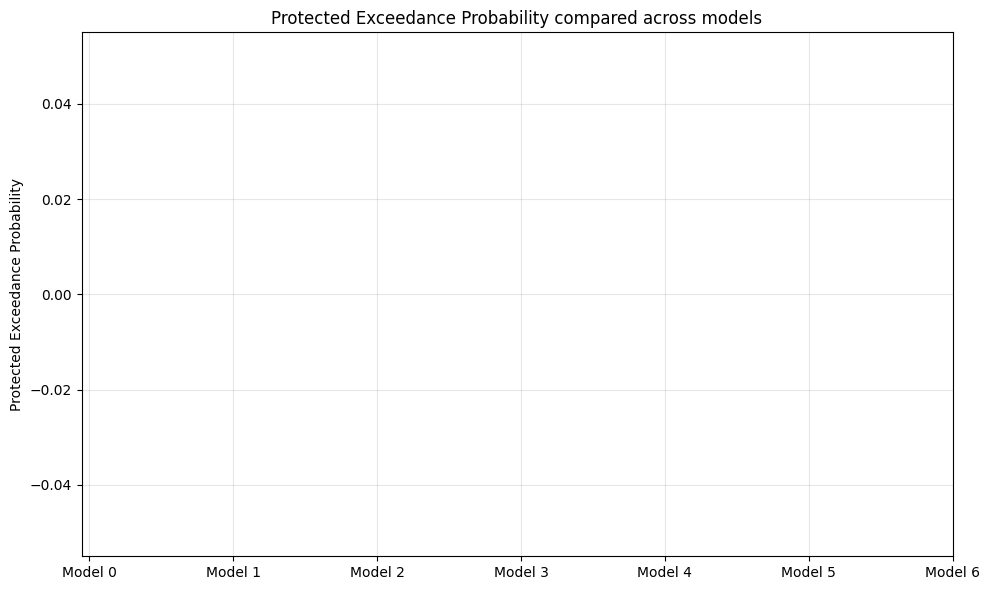

In [15]:
# Create the plot
plt.figure(figsize=(10, 6))

# Create x-axis positions
x_positions = range(len(bms_result))

only_plot_pxp = True

# Plot both lines
if only_plot_pxp:
    plt.plot(x_positions, bms_result['pxp'], marker='o', label='Protected Exceedance Probability', linewidth=2)
else:
    plt.plot(x_positions, bms_result['xp'], marker='o', label='Exceedance Probability', linewidth=2)
    plt.plot(x_positions, bms_result['pxp'], marker='o', label='Protected Exceedance Probability', linewidth=2)

# Set x-axis labels
x_labels = [f'Model {i}' for i in range(len(bms_result))]
plt.xticks(x_positions, x_labels)

# Add labels and title
if only_plot_pxp:
    plt.ylabel('Protected Exceedance Probability')
    plt.title('Protected Exceedance Probability compared across models')
else:
    plt.ylabel('(Protected) Exceedance Probability')
    plt.title('Exceedance Probability and Protected Exceedance Probability compared across models')
    plt.legend()
plt.grid(True, alpha=0.3)

# Display the plot
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'bayesian_model_comparison.pdf'))
plt.show()